Download flower-dataset

## Ladda ner dataset från Kaggle

Använder `kagglehub` för att automatiskt ladda ner **Signs Detection Dataset** från Kaggle. Sökvägen till den nedladdade datan sparas i variabeln `path` och används i efterföljande celler.

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maneesh99/signs-detection-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/cryptofarian/.cache/kagglehub/datasets/maneesh99/signs-detection-dataset/versions/2


## Utforska HDF5-filens struktur

Öppnar träningsfilen (`Signs_Data_Training.h5`) med `h5py` och skriver ut alla nycklar (dataset-namn) tillsammans med deras form och datatyp. Detta ger en översikt av hur datan är organiserad i HDF5-formatet.

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

train_path = path + "/Signs_Data_Training.h5"

with h5py.File(train_path, "r") as f:
    print("Nycklar i träningsfilen:", list(f.keys()))
    for key in f.keys():
        print(f"  {key}: shape={f[key].shape}, dtype={f[key].dtype}")

Nycklar i träningsfilen: ['list_classes', 'train_set_x', 'train_set_y']
  list_classes: shape=(6,), dtype=int64
  train_set_x: shape=(1080, 64, 64, 3), dtype=uint8
  train_set_y: shape=(1080,), dtype=int64


## Ladda bilder och etiketter – visualisera stickprov

Läser in alla bilder och deras etiketter från HDF5-filen. Bildnyckeln identifieras automatiskt som den array med 4 dimensioner (N, H, W, C), och etikettnyckeln väljs som den array vars antal element matchar antalet bilder. Pixelvärdena normaliseras till intervallet [0, 1] om de är i [0, 255]. Avslutningsvis ritas 16 slumpmässigt valda bilder upp i ett 4×4-rutnät.

Bilder: (1080, 64, 64, 3)  |  Etiketter: (1080,)
Pixelvärden: min=4, max=244


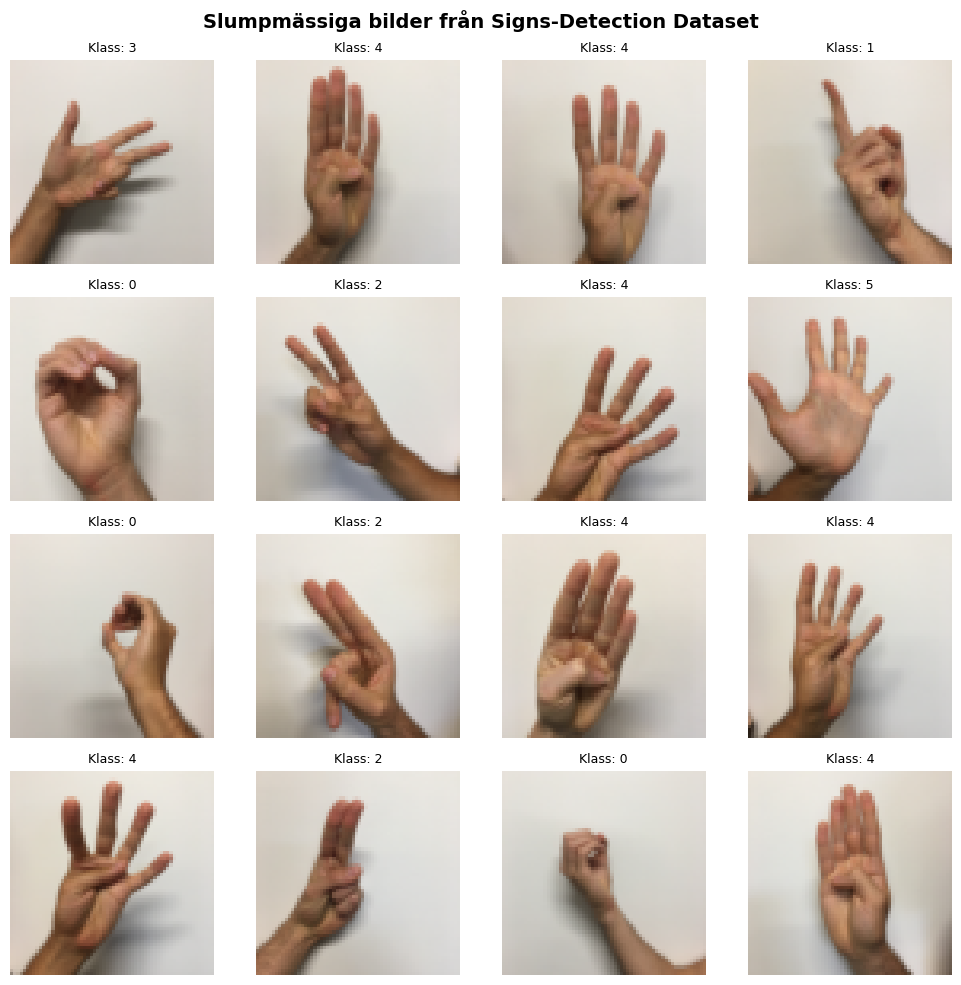

In [5]:
with h5py.File(train_path, "r") as f:
    keys = list(f.keys())
    image_key = next(k for k in keys if len(f[k].shape) == 4)
    n_samples = f[image_key].shape[0]
    # Välj etikettnyckeln vars antal element matchar antalet bilder,
    # och undvik listor med klassnamn (t.ex. list_classes med bara 6 element)
    label_key = next(
        k for k in keys
        if k != image_key and f[k].size == n_samples
    )
    images = f[image_key][:]
    labels = f[label_key][:].flatten()

print(f"Bilder: {images.shape}  |  Etiketter: {labels.shape}")
print(f"Pixelvärden: min={images.min()}, max={images.max()}")

if images.max() > 1:
    images = images / 255.0

n = 16
indices = np.random.choice(len(images), n, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("Slumpmässiga bilder från Signs-Detection Dataset", fontsize=14, fontweight="bold")

for ax, idx in zip(axes.flat, indices):
    img = images[idx]
    ax.imshow(img)
    ax.set_title(f"Klass: {labels[idx]}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


## Importera PyTorch

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Använder enhet: {DEVICE}")


Använder enhet: cuda


## Definiera `SignsDataset` – anpassad PyTorch-dataklass

Skapar en klass som ärver från `torch.utils.data.Dataset`. Konstruktorn läser in hela datasetet från HDF5-filen, normaliserar pixelvärdena till [0, 1] och sparar bilderna som float32. Metoden `__getitem__` konverterar en bild till en CHW-tensor (kanaler × höjd × bredd) och applicerar valfria transforms.

In [7]:
class SignsDataset(Dataset):
    """Laddar Signs-datasetet från en HDF5-fil."""

    def __init__(self, h5_path, transform=None):
        with h5py.File(h5_path, "r") as f:
            keys = list(f.keys())
            image_key = next(k for k in keys if len(f[k].shape) == 4)
            n = f[image_key].shape[0]
            label_key = next(k for k in keys if k != image_key and f[k].size == n)
            self.images = f[image_key][:].astype("float32") / 255.0
            self.labels = f[label_key][:].flatten().astype("int64")
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        img = torch.from_numpy(self.images[i]).permute(2, 0, 1)  # HWC → CHW
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[i])


## Definiera CNN-arkitektur – `conv_block` och `MediumCNN`

`conv_block` är en hjälpfunktion som bygger ett konvolutionsblock bestående av Conv2d → BatchNorm2d → ReLU → (valfri) MaxPool2d.

`MediumCNN` är det neurala nätverket som används för klassificering:
- **Feature extractor**: två konvolutionsblock som reducerar bildstorleken 64×64 → 32×32 → 16×16 medan antalet kanaler ökar (32, 64).
- **Classifier**: ett fullkopplat lager med Dropout följt av ett utgångslager med `num_classes` = 6 neuroner (en per tecken-klass).

In [8]:
def conv_block(in_ch, out_ch, kernel=3, pool=True):
    """Conv → BatchNorm → ReLU → MaxPool"""
    layers = [
        nn.Conv2d(in_ch, out_ch, kernel_size=kernel, padding=kernel // 2),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    ]
    if pool:
        layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)


class MediumCNN(nn.Module):
    """
    MediumCNN anpassad för detta dtaset från del 2.
    Input: (N, 3, 64, 64)  →  64 → 32 → 16 efter 2x MaxPool
    """
    def __init__(self, in_channels=3, num_classes=6, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(in_channels, 32),   # 64 → 32
            conv_block(32, 64),            # 32 → 16
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = MediumCNN().to(DEVICE)


total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Träningsbara parametrar: {total_params:,}")


Träningsbara parametrar: 8,411,782


## Data augmentation


### Definiera transformations-pipelines

Skapar två separata pipelines med `torchvision.transforms`:

**Tränings-pipeline** (`train_transform`) inkluderar data augmentation för att öka modellens robusthet:
- Slumpmässig horisontell spegling
- Slumpmässig rotation (±15°)
- Slumpmässig zoom och crop
- Färgjustering (ljusstyrka, kontrast, mättnad)
- Sällsynt gråskalning (5 % av fallen)
- Lätt Gaussisk oskärpa
- Normalisering med medelvärde 0,5 och standardavvikelse 0,5 per kanal

**Test-pipeline** (`test_transform`) utför enbart normalisering utan augmentation.

In [9]:
BATCH_SIZE = 32

# Normalisering beräknad på SIGNS-träningsdata (RGB, [0,1])
MEAN = (0.5, 0.5, 0.5)
STD  = (0.5, 0.5, 0.5)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),  # Slumpmässig zoom/crop
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),  # Färgvariation
    transforms.RandomGrayscale(p=0.05),  # Ibland gråskala
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),  # Lätt oskärpa
    transforms.Normalize(MEAN, STD),
])

test_transform = transforms.Compose([
    transforms.Normalize(MEAN, STD),
])


## Dela upp data i tränings- och valideringsset

Laddar hela träningsdatasetet utan transforms. Delar det sedan 80/20 i träning och validering med ett fast slumpfrö (`seed=42`) för reproducerbarhet.

`TransformDataset` är en wrapper-klass som applicerar en transform-pipeline *on-the-fly* på ett `Subset`, utan att behöva kopiera data. Slutligen skapas `DataLoader`-objekt för effektiv batch-läsning med parallell laddning (`num_workers=4`).

In [10]:


# Sätt train_transform=None i datasetet vid inladdning
full_train = SignsDataset(train_path, transform=None)
val_size   = int(0.2 * len(full_train))
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(42))

# Applicera transforms via en wrapper
from torch.utils.data import Subset

class TransformDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, i):
        img, label = self.subset[i]
        return self.transform(img), label

train_set = TransformDataset(train_set, train_transform)
val_set   = TransformDataset(val_set,   test_transform)

test_set = SignsDataset(path + "/Signs_Data_Testing.h5", transform=test_transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Träning: {len(train_set)} | Validering: {len(val_set)} | Test: {len(test_set)}")


Träning: 864 | Validering: 216 | Test: 120


## Visualisera effekten av varje augmentation-steg

Hämtar en råbild (utan transforms) från datasetet och visar hur bilden förändras efter varje enskilt transformationssteg (flip, rotation, crop, färgjustering, gråskala, oskärpa, normalisering). En andra del visar fem slumpmässigt augmenterade versioner av samma bild sida vid sida för att illustrera variationen under träning.

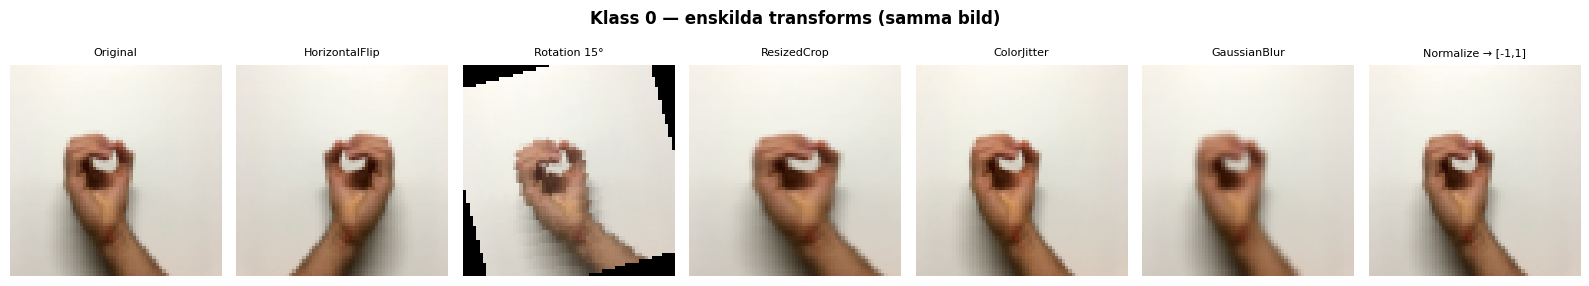

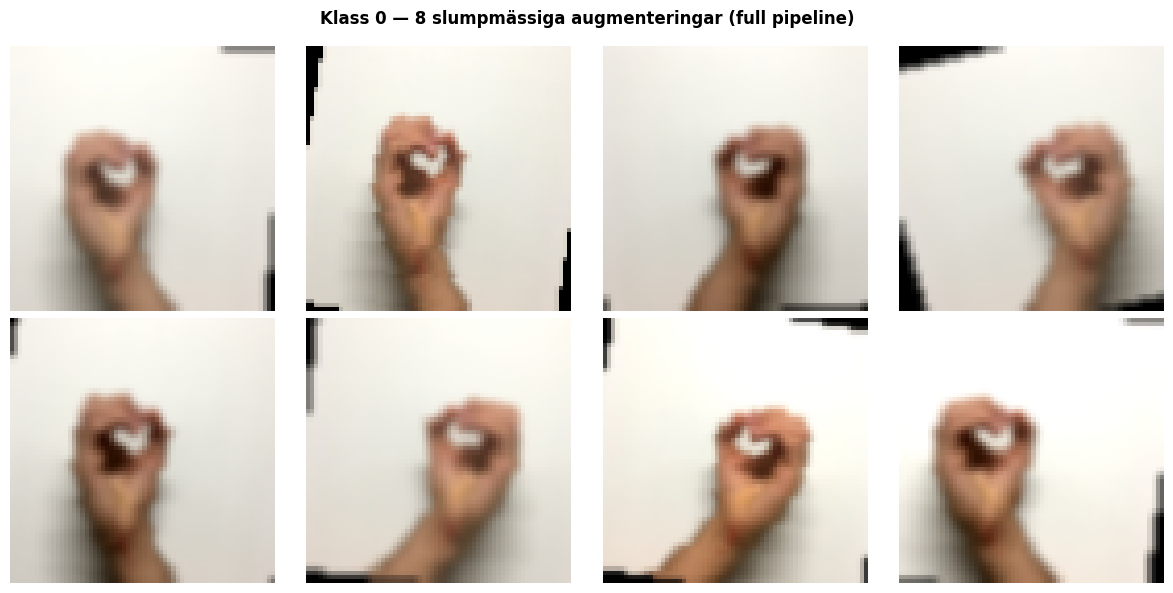

In [11]:
import torchvision.transforms.functional as TF

# Hämta en råbild (utan transforms) från full_train
sample_idx = 42
raw_img, label = full_train[sample_idx]   # CHW, float [0,1]

def to_numpy(t):
    """Konverterar tensor CHW [0,1] eller [-1,1] till HWC [0,1] för imshow."""
    img = t.permute(1, 2, 0).numpy()
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

normalize = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

# ── Del 1: Original vs varje transform steg för steg ──
aug_steps = {
    "Original":              raw_img,
    "HorizontalFlip":        TF.hflip(raw_img),
    "Rotation 15°":          TF.rotate(raw_img, 15),
    "ResizedCrop":           transforms.RandomResizedCrop(64, scale=(0.8, 1.0))(raw_img),
    "ColorJitter":           transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                                    saturation=0.2)(raw_img),
    "GaussianBlur":          TF.gaussian_blur(raw_img, kernel_size=3),
    "Normalize → [-1,1]":   normalize(raw_img),
}

fig, axes = plt.subplots(1, len(aug_steps), figsize=(16, 3))
fig.suptitle(f"Klass {label} — enskilda transforms (samma bild)", fontsize=12, fontweight="bold")
for ax, (name, t) in zip(axes, aug_steps.items()):
    ax.imshow(to_numpy(t))
    ax.set_title(name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

# ── Del 2: Slumpmässig variation — 8 körningar av hela train_transform ──
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle(f"Klass {label} — 8 slumpmässiga augmenteringar (full pipeline)", fontsize=12, fontweight="bold")
for ax in axes.flat:
    aug = train_transform(raw_img)
    ax.imshow(to_numpy(aug))
    ax.axis("off")
plt.tight_layout()
plt.show()


## Sätta upp träning och träna modellen

Definierar hyperparametrar: 15 epoker, inlärningshastighet 1e-3 och viktnedbrytning 1e-4.

Initierar `MediumCNN`, Adam-optimeraren och en `CosineAnnealingLR`-scheduler som successivt sänker inlärningshastigheten. Förlustfunktionen är `CrossEntropyLoss`.

`run_epoch` kör ett tränings- eller valideringssteg för hela datasetet: beräknar forward pass, förlust, backward pass (vid träning), och samlar in loss och accuracy. Träningshistoriken sparas per epok.

In [12]:
EPOCHS = 15
LR     = 1e-3
WD     = 1e-4

model     = MediumCNN().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}


def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            if train:
                optimizer.zero_grad()
            out  = model(X)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (out.argmax(1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = run_epoch(train_loader, train=True)
    v_loss, v_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    print(f"Epok {epoch:2d}/{EPOCHS} | "
          f"train_loss={t_loss:.4f} acc={t_acc:.3f} | "
          f"val_loss={v_loss:.4f} acc={v_acc:.3f}")

# Testaccuracy
_, test_acc = run_epoch(test_loader, train=False)
print(f"\nTestaccuracy: {test_acc:.3f}")


Epok  1/15 | train_loss=4.2579 acc=0.240 | val_loss=1.6548 acc=0.389
Epok  2/15 | train_loss=1.5361 acc=0.366 | val_loss=1.2734 acc=0.556
Epok  3/15 | train_loss=1.4219 acc=0.434 | val_loss=1.1035 acc=0.630
Epok  4/15 | train_loss=1.2902 acc=0.478 | val_loss=0.9866 acc=0.657
Epok  5/15 | train_loss=1.2256 acc=0.524 | val_loss=0.9181 acc=0.690
Epok  6/15 | train_loss=1.1454 acc=0.553 | val_loss=0.9332 acc=0.611
Epok  7/15 | train_loss=1.0916 acc=0.576 | val_loss=0.7884 acc=0.764
Epok  8/15 | train_loss=1.0044 acc=0.615 | val_loss=0.7261 acc=0.731
Epok  9/15 | train_loss=0.9123 acc=0.649 | val_loss=0.6560 acc=0.745
Epok 10/15 | train_loss=0.8891 acc=0.674 | val_loss=0.6236 acc=0.801
Epok 11/15 | train_loss=0.8841 acc=0.676 | val_loss=0.5974 acc=0.829
Epok 12/15 | train_loss=0.9011 acc=0.664 | val_loss=0.5579 acc=0.829
Epok 13/15 | train_loss=0.8374 acc=0.708 | val_loss=0.5518 acc=0.833
Epok 14/15 | train_loss=0.7986 acc=0.716 | val_loss=0.5419 acc=0.829
Epok 15/15 | train_loss=0.8453 acc

## Visualisera träningsresultat

Plottar tränings- och valideringsförlust (loss) samt noggrannhet (accuracy) som funktion av epok i ett 1×2-diagram. Graferna används för att bedöma om modellen överanpassar (overfitting) eller underanpassar (underfitting) och hur snabbt inlärningen konvergerar.

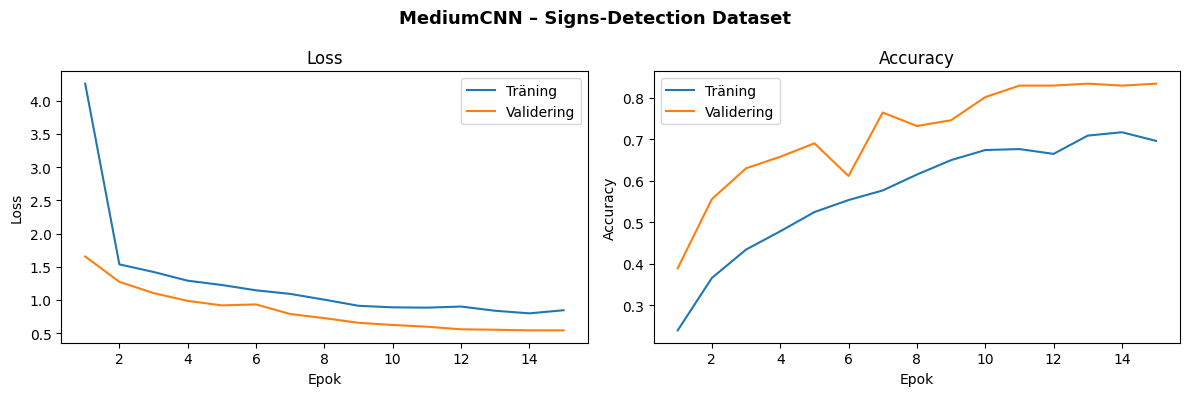

In [13]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("MediumCNN – Signs-Detection Dataset", fontsize=13, fontweight="bold")

ax1.plot(epochs_range, history["train_loss"], label="Träning")
ax1.plot(epochs_range, history["val_loss"],   label="Validering")
ax1.set_xlabel("Epok")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend()

ax2.plot(epochs_range, history["train_acc"], label="Träning")
ax2.plot(epochs_range, history["val_acc"],   label="Validering")
ax2.set_xlabel("Epok")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()


## Slututvärdering på testdata

Den här cellen bör köras efter träningsgrafen. Den mäter modellen på testsetet, räknar ut per-klass-accuracy och visar en confusion matrix. Det gör att resultatdelen inte bara bygger på valideringsdata.


Bästa validering: epoch 13, val_acc=0.833, val_loss=0.552
Testresultat MediumCNN: loss=0.571, accuracy=0.808

Per-klass accuracy:
  Klass 0: 0.950  (n=20)
  Klass 1: 0.950  (n=20)
  Klass 2: 0.600  (n=20)
  Klass 3: 0.900  (n=20)
  Klass 4: 0.650  (n=20)
  Klass 5: 0.800  (n=20)


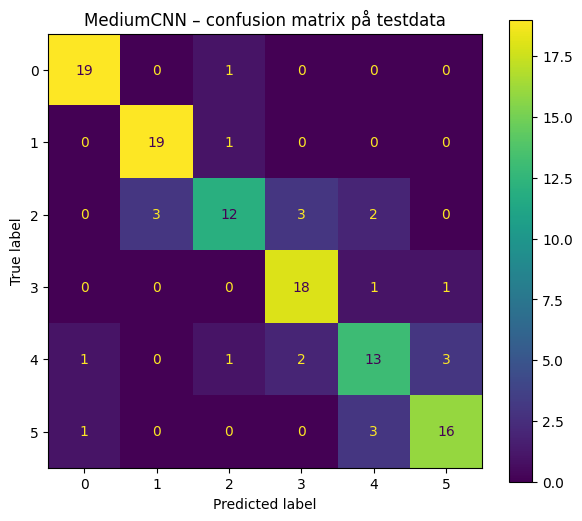

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Sammanfatta bästa valideringsresultat
best_val_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])
best_val_loss = history["val_loss"][best_val_epoch - 1]
print(f"Bästa validering: epoch {best_val_epoch}, val_acc={best_val_acc:.3f}, val_loss={best_val_loss:.3f}")

# Testutvärdering
model.eval()
all_preds, all_labels = [], []
test_loss, test_correct, test_total = 0.0, 0, 0

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        logits = model(X)
        loss = criterion(logits, y)

        preds = logits.argmax(dim=1)
        test_loss += loss.item() * X.size(0)
        test_correct += (preds == y).sum().item()
        test_total += y.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

test_loss /= test_total
test_acc = test_correct / test_total
print(f"Testresultat MediumCNN: loss={test_loss:.3f}, accuracy={test_acc:.3f}")

# Per-klass accuracy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
classes = sorted(np.unique(all_labels))

print("\nPer-klass accuracy:")
for cls in classes:
    mask = all_labels == cls
    cls_acc = (all_preds[mask] == all_labels[mask]).mean()
    print(f"  Klass {cls}: {cls_acc:.3f}  (n={mask.sum()})")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
ax.set_title("MediumCNN – confusion matrix på testdata")
plt.show()
